## PREDICTING H1N1 AND SEASONAL FLU VACCINES- PHASE 3 PROJECT

### PROJECT OVERVIEW

Vaccinations play a critical role in controlling infectious diseases by protecting individuals and contributing to herd immunity, making it an essential area of study in public health. This project focuses on predicting whether individuals received the H1N1 and seasonal vaccines using demographic, behavioral, and attitudinal data collected during the 2009 H1N1 flu pandemic.
 Using machine learning models, the analysis identifies key factors that influence vaccination decisions and estimates the likelihood of vaccine uptake. The insights gained can help improve public health strategies and guide more effective responses to future infectious disease outbreaks.

### BUSINESS PROBLEM

Public health organizations often face challenges in achieving high vaccination rates due to differences in individuals’ beliefs, behaviors, and access to healthcare. Without a clear understanding of these factors, it is difficult to design effective vaccination campaigns and allocate resources efficiently.

The goal of this project is to predict the likelihood that individuals received the H1N1 and seasonal flu vaccines, by estimating two probabilities: one for h1n1_vaccine and one for seasonal_vaccine. By identifying individuals who were less likely to have been vaccinated and understanding the factors influencing their decisions, stakeholders can implement targeted interventions, improve vaccine uptake, and reduce the spread of infectious diseases.

#### Project stakeholders
The stakeholders include:
1. Public Health Agencies: Tasked to gather insights to design vaccination
                             campaigns and policies.
2. Healthcare providers: Concerned with identifying and encouraging patients who are
                          less likely to get vaccinated.
3. Researchers & Data Scientists: Tasked to analyze trends and
                                     improve predictive health models.



## BUSINESS UNDERSTANDING

The main objective and challenge is to predict how likely individuals received either or both of their two vaccines:

•	H1N1 vaccine

•	Seasonal flu vaccine

Specifically, the model must output:

•	Probability of receiving h1n1_vaccine

•	Probability of receiving seasonal_vaccine

•   Probability of receiving both of the vaccines


This enables better targeting of interventions and efficient allocation of public health resources.

### Objectives

1. Identify which vaccine has been effective.
2. Predict vaccination probabilities for each individual.
3. Identify key factors influencing vaccine uptake.
4. Improve decision-making for public health campaigns.


### KEY QUESTIONS
1. What are the key factors affecting vaccine uptake?
2. What is the probability that individuals got the two vaccines?
3. Probability that individuals got either of the vaccines?
4. What is the probability that individuals did not get either of the vaccines?
5. What vaccine has been effective?







________________________________________





## DATA UNDERSTANDING

The dataset consists of 26,707 records, representing survey responses during the 2009 H1N1 pandemic. There are 36 features categorized into three main types:

•	Behavioral Features: Protective measures taken like behavioral_wash_hands and behavioral_face_mask.

•	Demographic Features: Personal information like age_group, education, race, sex.

•	Attitudinal Features: Beliefs about the flu and the vaccines like opinion_h1n1_risk, opinion_h1n1_vacc_effective.

My Target Variables: The two binary labels we want to predict: h1n1_vaccine and seasonal_vaccine.


### DATA LOADING AND PREPARATION

#### Importing important Libraries

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [5]:
features = pd.read_csv('training_set_features.csv')
labels = pd.read_csv('training_set_labels.csv')


#### Merge my datasets to one dataframe
To avoid data leakage we merge this 2 datasets to split again. The test_set feature.csv is not used.

In [6]:

new_merged = pd.merge(features, labels, on='respondent_id').set_index('respondent_id')
new_merged.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
respondent_id,,,,,,,,,,,,,,,,,,,,,
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,NaN,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


### EXPLORING AND FAMILIARIZING WITH THE DATA(EDA)

In [7]:
new_merged.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6084 entries, 0 to 6083
Data columns (total 37 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 6060 non-null   float64
 1   h1n1_knowledge               6058 non-null   float64
 2   behavioral_antiviral_meds    6068 non-null   float64
 3   behavioral_avoidance         6028 non-null   float64
 4   behavioral_face_mask         6077 non-null   float64
 5   behavioral_wash_hands        6078 non-null   float64
 6   behavioral_large_gatherings  6064 non-null   float64
 7   behavioral_outside_home      6059 non-null   float64
 8   behavioral_touch_face        6051 non-null   float64
 9   doctor_recc_h1n1             5589 non-null   float64
 10  doctor_recc_seasonal         5589 non-null   float64
 11  chronic_med_condition        5874 non-null   float64
 12  child_under_6_months         5907 non-null   float64
 13  health_worker          

In [8]:
new_merged.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation', 'h1n1_vaccine', 'seasonal_vaccine'],
      dtype='object')

In [9]:
new_merged.shape

(6084, 37)

In [10]:
new_merged.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,h1n1_vaccine,seasonal_vaccine
count,6060.000000,6058.000000,6068.000000,6028.000000,6077.000000,6078.000000,6064.000000,6059.000000,6051.000000,5589.000000,...,5987.000000,5998.000000,5995.000000,5980.000000,5972.000000,5963.000000,6031.000000,6031.000000,6084.000000,6084.000000
mean,1.582838,1.258336,0.052900,0.712342,0.068619,0.815729,0.357190,0.329592,0.670137,0.221864,...,3.856522,2.341781,2.335780,4.025251,2.729069,2.082341,0.884099,0.552645,0.216634,0.469099
std,0.908544,0.621382,0.223853,0.452708,0.252827,0.387737,0.479211,0.470104,0.470202,0.415538,...,0.997303,1.284023,1.362364,1.097305,1.395115,1.320151,0.751779,0.944657,0.411985,0.499085
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000,0.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,5.000000,4.000000,4.000000,5.000000,4.000000,2.000000,1.000000,1.000000,0.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000,1.000000,1.000000




```
# This is formatted as code
```

#### MISSING VALUES
Columns with high percentage of missing values are dropped since they are irrelevant to my analysis.

In [11]:
missing = new_merged.isna().sum().sort_values(ascending=False)
missing_pct = (missing / len(new_merged) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0]

,Missing Count,Missing %
employment_occupation,3079,50.61
employment_industry,3053,50.18
health_insurance,2785,45.78
income_poverty,978,16.07
doctor_recc_h1n1,495,8.14
doctor_recc_seasonal,495,8.14
rent_or_own,479,7.87
employment_status,342,5.62
marital_status,328,5.39
education,324,5.33


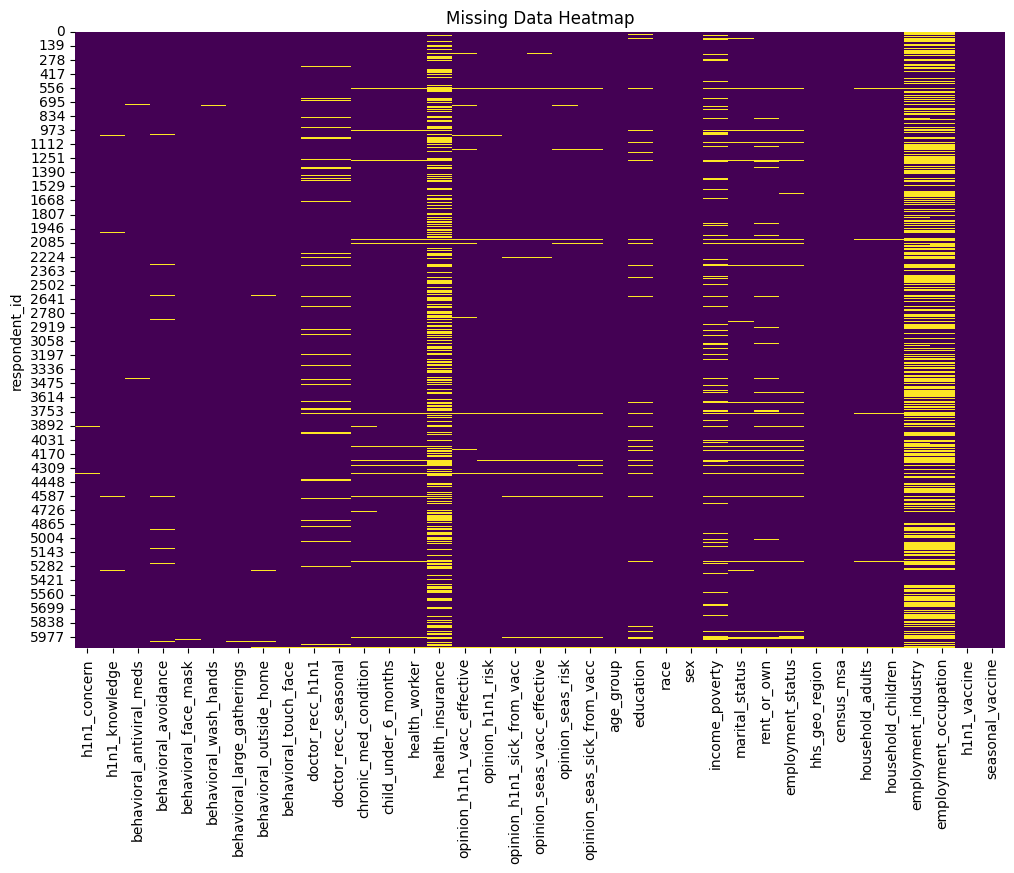

In [12]:
plt.figure(figsize=(12, 8))

# Missing Data Heatmap
sns.heatmap(new_merged.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Data Heatmap")
plt.show()

In [13]:
new_merged.isna().sum()

,0
h1n1_concern,24
h1n1_knowledge,26
behavioral_antiviral_meds,16
behavioral_avoidance,56
behavioral_face_mask,7
behavioral_wash_hands,6
behavioral_large_gatherings,20
behavioral_outside_home,25
behavioral_touch_face,33
doctor_recc_h1n1,495


In [14]:
new_merged.duplicated().sum()

np.int64(0)

### Correlation — Numeric Features vs Targets

#### We check the correlation between the numerical features and target variables.

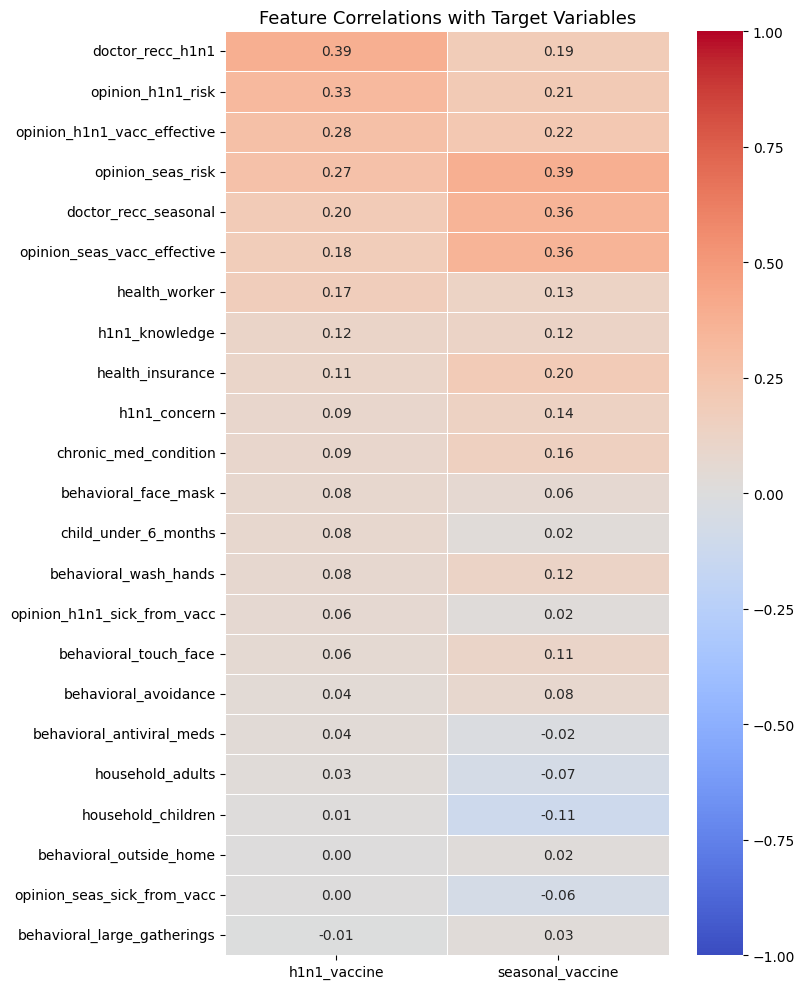

In [15]:
num_df = new_merged.select_dtypes(include='number')
corr_with_targets = num_df.corr()[['h1n1_vaccine', 'seasonal_vaccine']].drop(
    ['h1n1_vaccine', 'seasonal_vaccine']
).sort_values('h1n1_vaccine', ascending=False)

plt.figure(figsize=(8, 10))
sns.heatmap(corr_with_targets, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Feature Correlations with Target Variables', fontsize=13)
plt.tight_layout()
plt.show()

### Categorical Features — Vaccine Uptake by Group

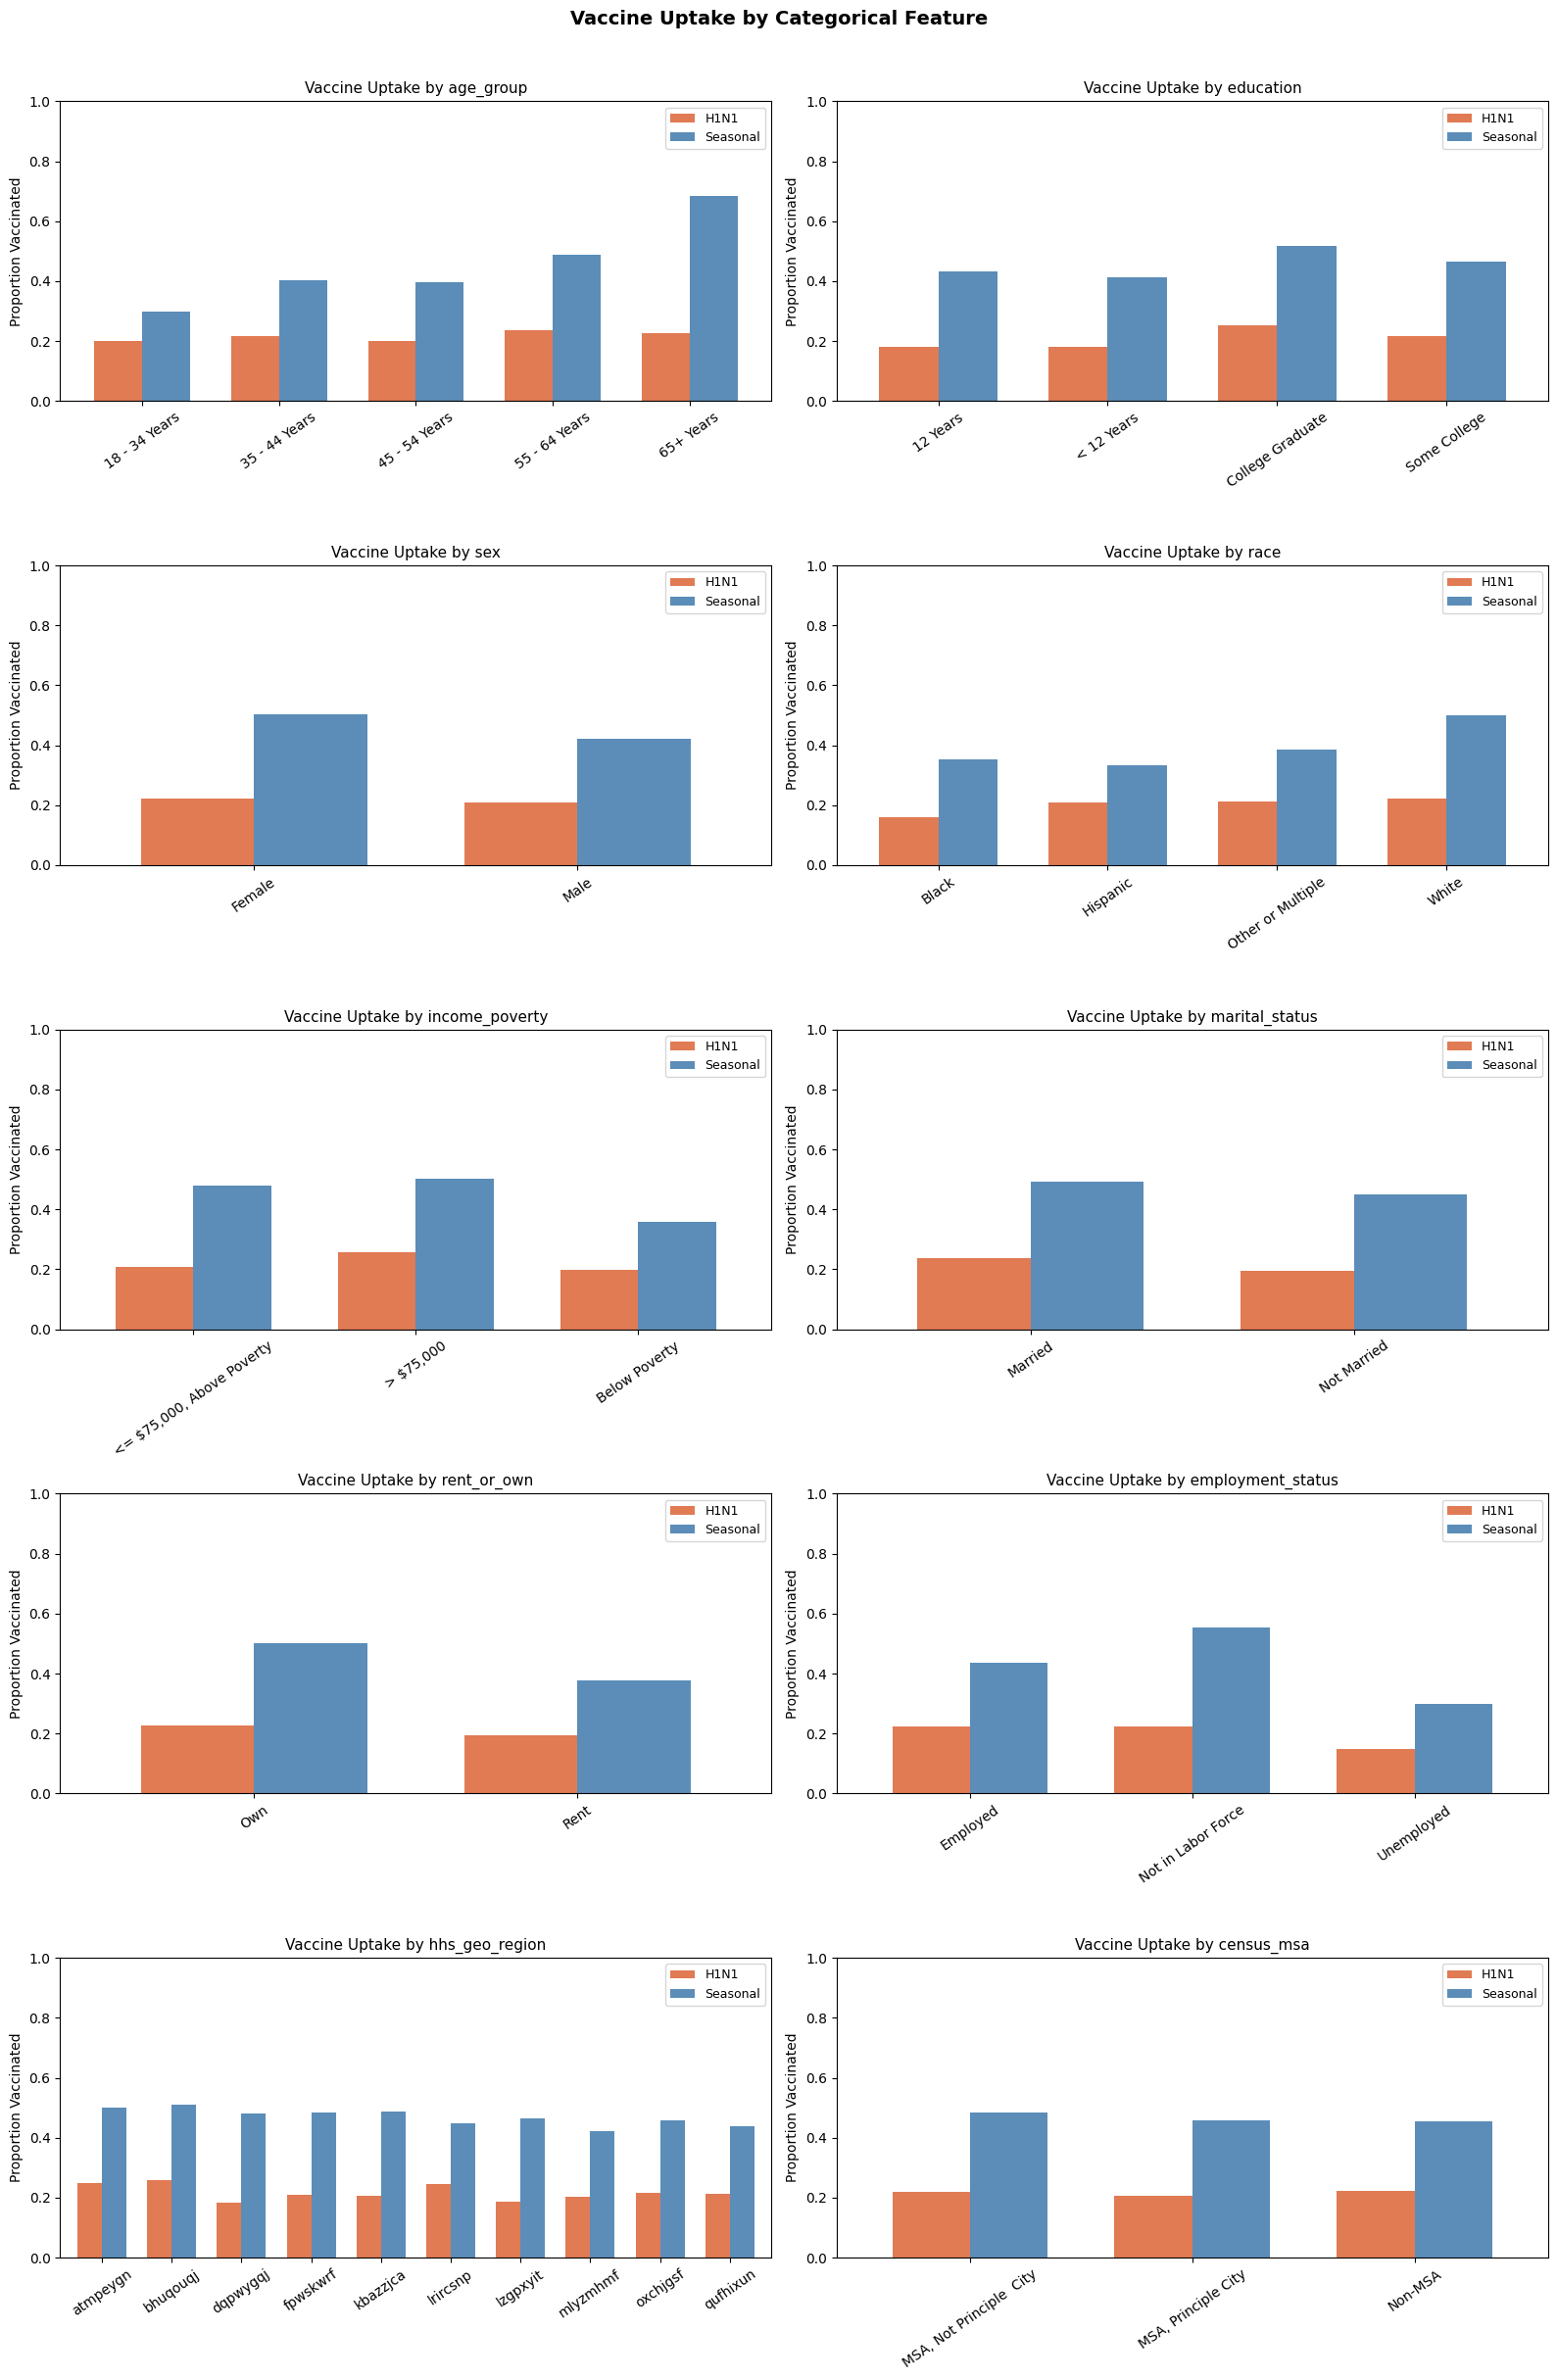

In [16]:
cat_features = [
    'age_group', 'education', 'sex', 'race',
    'income_poverty', 'marital_status', 'rent_or_own',
    'employment_status', 'hhs_geo_region', 'census_msa'
]

fig, axes = plt.subplots(5, 2, figsize=(16, 24))
axes = axes.flatten()

for i, col in enumerate(cat_features):
    uptake = new_merged.groupby(col)[['h1n1_vaccine', 'seasonal_vaccine']].mean()
    uptake.plot(kind='bar', ax=axes[i], color=['#e07b54', '#5b8db8'], width=0.7)
    axes[i].set_title(f'Vaccine Uptake by {col}', fontsize=11)
    axes[i].set_ylabel('Proportion Vaccinated')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=35)
    axes[i].legend(['H1N1', 'Seasonal'], fontsize=9)
    axes[i].set_ylim(0, 1)

plt.suptitle('Vaccine Uptake by Categorical Feature', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

#### GROUPING WHO GOT EITHER VACCINES, NONE, OR BOTH

In [17]:
def vaccine_group(row):
    if row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 1:
        return 'Both Vaccines'
    elif row['h1n1_vaccine'] == 1 and row['seasonal_vaccine'] == 0:
        return 'H1N1 Only'
    elif row['h1n1_vaccine'] == 0 and row['seasonal_vaccine'] == 1:
        return 'Seasonal Only'
    else:
        return 'Neither Vaccine'
new_merged['vaccine_group'] = new_merged.apply(vaccine_group, axis=1)

In [18]:
# Count and percentage
group_counts = new_merged['vaccine_group'].value_counts()
group_pct    = (group_counts / len(new_merged) * 100).round(1)
print(pd.DataFrame({'Count': group_counts, '%': group_pct}))

                 Count     %
vaccine_group               
Neither Vaccine   2999  49.3
Seasonal Only     1767  29.0
Both Vaccines     1087  17.9
H1N1 Only          231   3.8


### Defining my X and Y variables

In [19]:
X = new_merged.drop(columns=['h1n1_vaccine', 'seasonal_vaccine','vaccine_group'])

y = new_merged[['h1n1_vaccine', 'seasonal_vaccine']]

### SPLITTING MY DATA

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [21]:
X_train.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
5378,2.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,Below Poverty,Not Married,Own,Not in Labor Force,atmpeygn,"MSA, Principle City",0.0,0.0,NaN,NaN
861,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,mlyzmhmf,Non-MSA,0.0,0.0,xicduogh,qxajmpny
4561,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,...,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,lzgpxyit,"MSA, Principle City",0.0,0.0,NaN,NaN
903,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,"MSA, Principle City",2.0,1.0,atmlpfrs,xqwwgdyp
2093,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,NaN,NaN,NaN,fpwskwrf,"MSA, Principle City",1.0,2.0,NaN,NaN


In [22]:
y_train.head()

,h1n1_vaccine,seasonal_vaccine
respondent_id,,
5378,0,0
861,0,0
4561,0,0
903,0,0
2093,0,0


In [23]:
X_test.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation
respondent_id,,,,,,,,,,,,,,,,,,,,,
1046,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,...,Below Poverty,Not Married,Rent,Not in Labor Force,kbazzjca,Non-MSA,1.0,0.0,NaN,NaN
4058,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,"<= $75,000, Above Poverty",Married,Own,Employed,atmpeygn,Non-MSA,1.0,0.0,xicduogh,qxajmpny
4602,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,"<= $75,000, Above Poverty",Not Married,Own,Employed,atmpeygn,"MSA, Not Principle City",0.0,0.0,xicduogh,qxajmpny
2410,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,"> $75,000",Married,Own,Employed,lrircsnp,"MSA, Principle City",1.0,2.0,wxleyezf,emcorrxb
167,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,Below Poverty,Married,Rent,Not in Labor Force,dqpwygqj,"MSA, Principle City",1.0,0.0,NaN,NaN


#### EXPLORING MY SPLIT DATA

#### FOR X_TRAIN

In [24]:
X_train.info()



<class 'pandas.core.frame.DataFrame'>
Index: 4867 entries, 5378 to 860
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 4844 non-null   float64
 1   h1n1_knowledge               4843 non-null   float64
 2   behavioral_antiviral_meds    4857 non-null   float64
 3   behavioral_avoidance         4819 non-null   float64
 4   behavioral_face_mask         4860 non-null   float64
 5   behavioral_wash_hands        4863 non-null   float64
 6   behavioral_large_gatherings  4852 non-null   float64
 7   behavioral_outside_home      4844 non-null   float64
 8   behavioral_touch_face        4839 non-null   float64
 9   doctor_recc_h1n1             4499 non-null   float64
 10  doctor_recc_seasonal         4499 non-null   float64
 11  chronic_med_condition        4691 non-null   float64
 12  child_under_6_months         4723 non-null   float64
 13  health_worker        

In [25]:
X_train.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation'],
      dtype='object')

In [26]:
X_train.shape

(4867, 35)

In [27]:
X_train.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,4844.000000,4843.000000,4857.000000,4819.000000,4860.000000,4863.000000,4852.000000,4844.000000,4839.000000,4499.000000,...,4726.000000,2657.000000,4783.000000,4795.000000,4790.000000,4779.000000,4776.000000,4765.000000,4825.000000,4825.000000
mean,1.580099,1.266364,0.054560,0.713219,0.066872,0.815135,0.356348,0.331544,0.668733,0.218938,...,0.116589,0.882951,3.853439,2.342649,2.338831,4.026784,2.733878,2.083945,0.889741,0.555233
std,0.911523,0.622182,0.227144,0.452306,0.249827,0.388228,0.478969,0.470817,0.470717,0.413572,...,0.320964,0.321540,0.994576,1.279636,1.361791,1.085173,1.393384,1.320288,0.755760,0.948020
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,2.000000,2.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,2.000000,1.000000,1.000000
max,3.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [28]:
X_train.isna().sum()

,0
h1n1_concern,23
h1n1_knowledge,24
behavioral_antiviral_meds,10
behavioral_avoidance,48
behavioral_face_mask,7
behavioral_wash_hands,4
behavioral_large_gatherings,15
behavioral_outside_home,23
behavioral_touch_face,28
doctor_recc_h1n1,368


In [29]:
X_train.duplicated().sum()

np.int64(0)

#### FOR X_TEST

In [30]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1217 entries, 1046 to 3855
Data columns (total 35 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   h1n1_concern                 1216 non-null   float64
 1   h1n1_knowledge               1215 non-null   float64
 2   behavioral_antiviral_meds    1211 non-null   float64
 3   behavioral_avoidance         1209 non-null   float64
 4   behavioral_face_mask         1217 non-null   float64
 5   behavioral_wash_hands        1215 non-null   float64
 6   behavioral_large_gatherings  1212 non-null   float64
 7   behavioral_outside_home      1215 non-null   float64
 8   behavioral_touch_face        1212 non-null   float64
 9   doctor_recc_h1n1             1090 non-null   float64
 10  doctor_recc_seasonal         1090 non-null   float64
 11  chronic_med_condition        1183 non-null   float64
 12  child_under_6_months         1184 non-null   float64
 13  health_worker       

In [31]:
X_test.columns

Index(['h1n1_concern', 'h1n1_knowledge', 'behavioral_antiviral_meds',
       'behavioral_avoidance', 'behavioral_face_mask', 'behavioral_wash_hands',
       'behavioral_large_gatherings', 'behavioral_outside_home',
       'behavioral_touch_face', 'doctor_recc_h1n1', 'doctor_recc_seasonal',
       'chronic_med_condition', 'child_under_6_months', 'health_worker',
       'health_insurance', 'opinion_h1n1_vacc_effective', 'opinion_h1n1_risk',
       'opinion_h1n1_sick_from_vacc', 'opinion_seas_vacc_effective',
       'opinion_seas_risk', 'opinion_seas_sick_from_vacc', 'age_group',
       'education', 'race', 'sex', 'income_poverty', 'marital_status',
       'rent_or_own', 'employment_status', 'hhs_geo_region', 'census_msa',
       'household_adults', 'household_children', 'employment_industry',
       'employment_occupation'],
      dtype='object')

In [32]:
X_test.shape

(1217, 35)

In [33]:
X_test.describe()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,health_worker,health_insurance,opinion_h1n1_vacc_effective,opinion_h1n1_risk,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children
count,1216.000000,1215.000000,1211.000000,1209.00000,1217.000000,1215.000000,1212.000000,1215.000000,1212.000000,1090.000000,...,1185.000000,642.000000,1204.000000,1203.000000,1205.000000,1201.000000,1196.000000,1198.000000,1206.000000,1206.000000
mean,1.593750,1.226337,0.046243,0.70885,0.075596,0.818107,0.360561,0.321811,0.675743,0.233945,...,0.099578,0.889408,3.868771,2.338321,2.323651,4.019151,2.709866,2.075960,0.861526,0.542289
std,0.896868,0.617401,0.210097,0.45448,0.264459,0.385915,0.480361,0.467363,0.468290,0.423532,...,0.299563,0.313871,1.008388,1.301894,1.365138,1.144756,1.402426,1.320138,0.735510,0.931399
min,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,1.000000,1.000000,0.000000,0.00000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,1.000000,3.000000,1.000000,1.000000,4.000000,2.000000,1.000000,0.000000,0.000000
50%,2.000000,1.000000,0.000000,1.00000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,1.000000,4.000000,2.000000,2.000000,4.000000,2.000000,2.000000,1.000000,0.000000
75%,2.000000,2.000000,0.000000,1.00000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,...,0.000000,1.000000,5.000000,4.000000,4.000000,5.000000,4.000000,2.000000,1.000000,1.000000
max,3.000000,2.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,3.000000,3.000000


In [34]:
X_test.isna().sum()

,0
h1n1_concern,1
h1n1_knowledge,2
behavioral_antiviral_meds,6
behavioral_avoidance,8
behavioral_face_mask,0
behavioral_wash_hands,2
behavioral_large_gatherings,5
behavioral_outside_home,2
behavioral_touch_face,5
doctor_recc_h1n1,127


In [35]:
X_test.duplicated().sum()

np.int64(0)

## DATA CLEANING AND PREPROCESSING

#### 1. Dropping unnecessary columns

In [36]:

new_X_train = X_train.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_train.head()


,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children
respondent_id,,,,,,,,,,,,,,,,,,,,,
5378,2.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,Some College,White,Female,Below Poverty,Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0
861,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,Some College,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,Non-MSA,0.0,0.0
4561,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,...,12 Years,Black,Male,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,"MSA, Principle City",0.0,0.0
903,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,< 12 Years,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,"MSA, Principle City",2.0,1.0
2093,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,NaN,Other or Multiple,Male,NaN,NaN,NaN,NaN,"MSA, Principle City",1.0,2.0


In [37]:
new_X_test = X_test.drop(["employment_industry","hhs_geo_region","employment_occupation"], axis=1)
new_X_test.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,race,sex,income_poverty,marital_status,rent_or_own,employment_status,census_msa,household_adults,household_children
respondent_id,,,,,,,,,,,,,,,,,,,,,
1046,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,NaN,...,12 Years,Black,Female,Below Poverty,Not Married,Rent,Not in Labor Force,Non-MSA,1.0,0.0
4058,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,...,12 Years,White,Male,"<= $75,000, Above Poverty",Married,Own,Employed,Non-MSA,1.0,0.0
4602,1.0,1.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,0.0,...,12 Years,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Employed,"MSA, Not Principle City",0.0,0.0
2410,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,College Graduate,White,Female,"> $75,000",Married,Own,Employed,"MSA, Principle City",1.0,2.0
167,2.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,12 Years,White,Female,Below Poverty,Married,Rent,Not in Labor Force,"MSA, Principle City",1.0,0.0


#### 2. FILLING MISSING VALUES

##### Filling Missing values for X_train

## Create copies of dataset
### We create copies , in order not to make permernent changes to our initial dataset.

In [38]:
#Filling Missing values for X_train
numerical_columns = new_X_train.select_dtypes(include='number').columns.tolist()
numerical_columns

['h1n1_concern',
 'h1n1_knowledge',
 'behavioral_antiviral_meds',
 'behavioral_avoidance',
 'behavioral_face_mask',
 'behavioral_wash_hands',
 'behavioral_large_gatherings',
 'behavioral_outside_home',
 'behavioral_touch_face',
 'doctor_recc_h1n1',
 'doctor_recc_seasonal',
 'chronic_med_condition',
 'child_under_6_months',
 'health_worker',
 'health_insurance',
 'opinion_h1n1_vacc_effective',
 'opinion_h1n1_risk',
 'opinion_h1n1_sick_from_vacc',
 'opinion_seas_vacc_effective',
 'opinion_seas_risk',
 'opinion_seas_sick_from_vacc',
 'household_adults',
 'household_children']

In [39]:
categorical_columns = new_X_train.select_dtypes(include='object').columns.tolist()

categorical_columns

['age_group',
 'education',
 'race',
 'sex',
 'income_poverty',
 'marital_status',
 'rent_or_own',
 'employment_status',
 'census_msa']

In [40]:
numerical_imputer = SimpleImputer(strategy='most_frequent')
categorical_imputer = SimpleImputer(strategy='most_frequent')
X_train_clean = X_train.copy()
X_train_clean_num = pd.DataFrame(numerical_imputer.fit_transform(X_train_clean[numerical_columns]), columns=numerical_columns, index=X_train_clean.index)
X_train_clean_cat = pd.DataFrame(categorical_imputer.fit_transform(X_train_clean[categorical_columns]), columns=categorical_columns, index=X_train_clean.index)

# X_train_num = pd.DataFrame(numerical_imputer.fit_transform(X_train_clean[numerical_columns]), columns=numerical_columns, index=X_train_clean.index)
# X_train_cat = pd.DataFrame(categorical_imputer.fit_transform(X_train_clean[categorical_columns]), columns=categorical_columns, index=X_train_clean.index)

##### Filling Missing values for X_test

In [41]:
X_test_clean = X_test.copy()
X_test_clean_num = pd.DataFrame(numerical_imputer.transform(X_test_clean[numerical_columns]), columns=numerical_columns, index=X_test_clean.index)
X_test_clean_cat= pd.DataFrame(categorical_imputer.transform(X_test_clean[categorical_columns]), columns=categorical_columns, index=X_test_clean.index)

# X_test_num = pd.DataFrame(numerical_imputer.transform(X_test_clean[numerical_columns]), columns=numerical_columns, index=X_test_clean.index)
# X_test_cat= pd.DataFrame(categorical_imputer.transform(X_test_clean[categorical_columns]), columns=categorical_columns, index=X_test_clean.index)


#### 3. Checking For Outliers
The numeric features in this dataset are either binary,0 or 1,or ordinal scales,1–5. Because the values are bounded, any extreme responses are still valid answers and not errors. The models to be used are also not heavily affected by outliers. No rows removed.

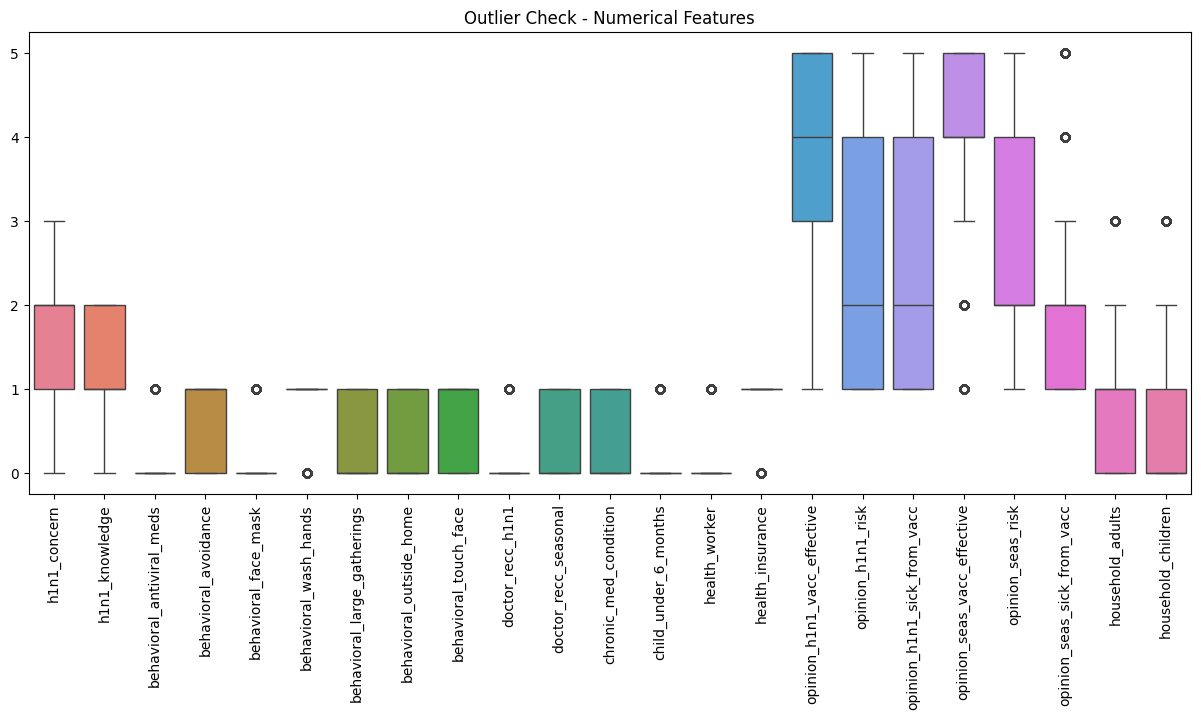

In [42]:
plt.figure(figsize=(15,6))
sns.boxplot(data=X_train[numerical_columns])
plt.xticks(rotation=90)
plt.title("Outlier Check - Numerical Features")
plt.show()

The boxplots reveal the presence of some outliers across numerical features, but they are not overly extreme or widespread. These values are retained as they may represent genuine variations rather than errors and are unlikely to significantly distort the models.

### EXPLORATORY DATA ANALYSIS- PART 2

#### 1. UNIVARIATE ANALYSIS

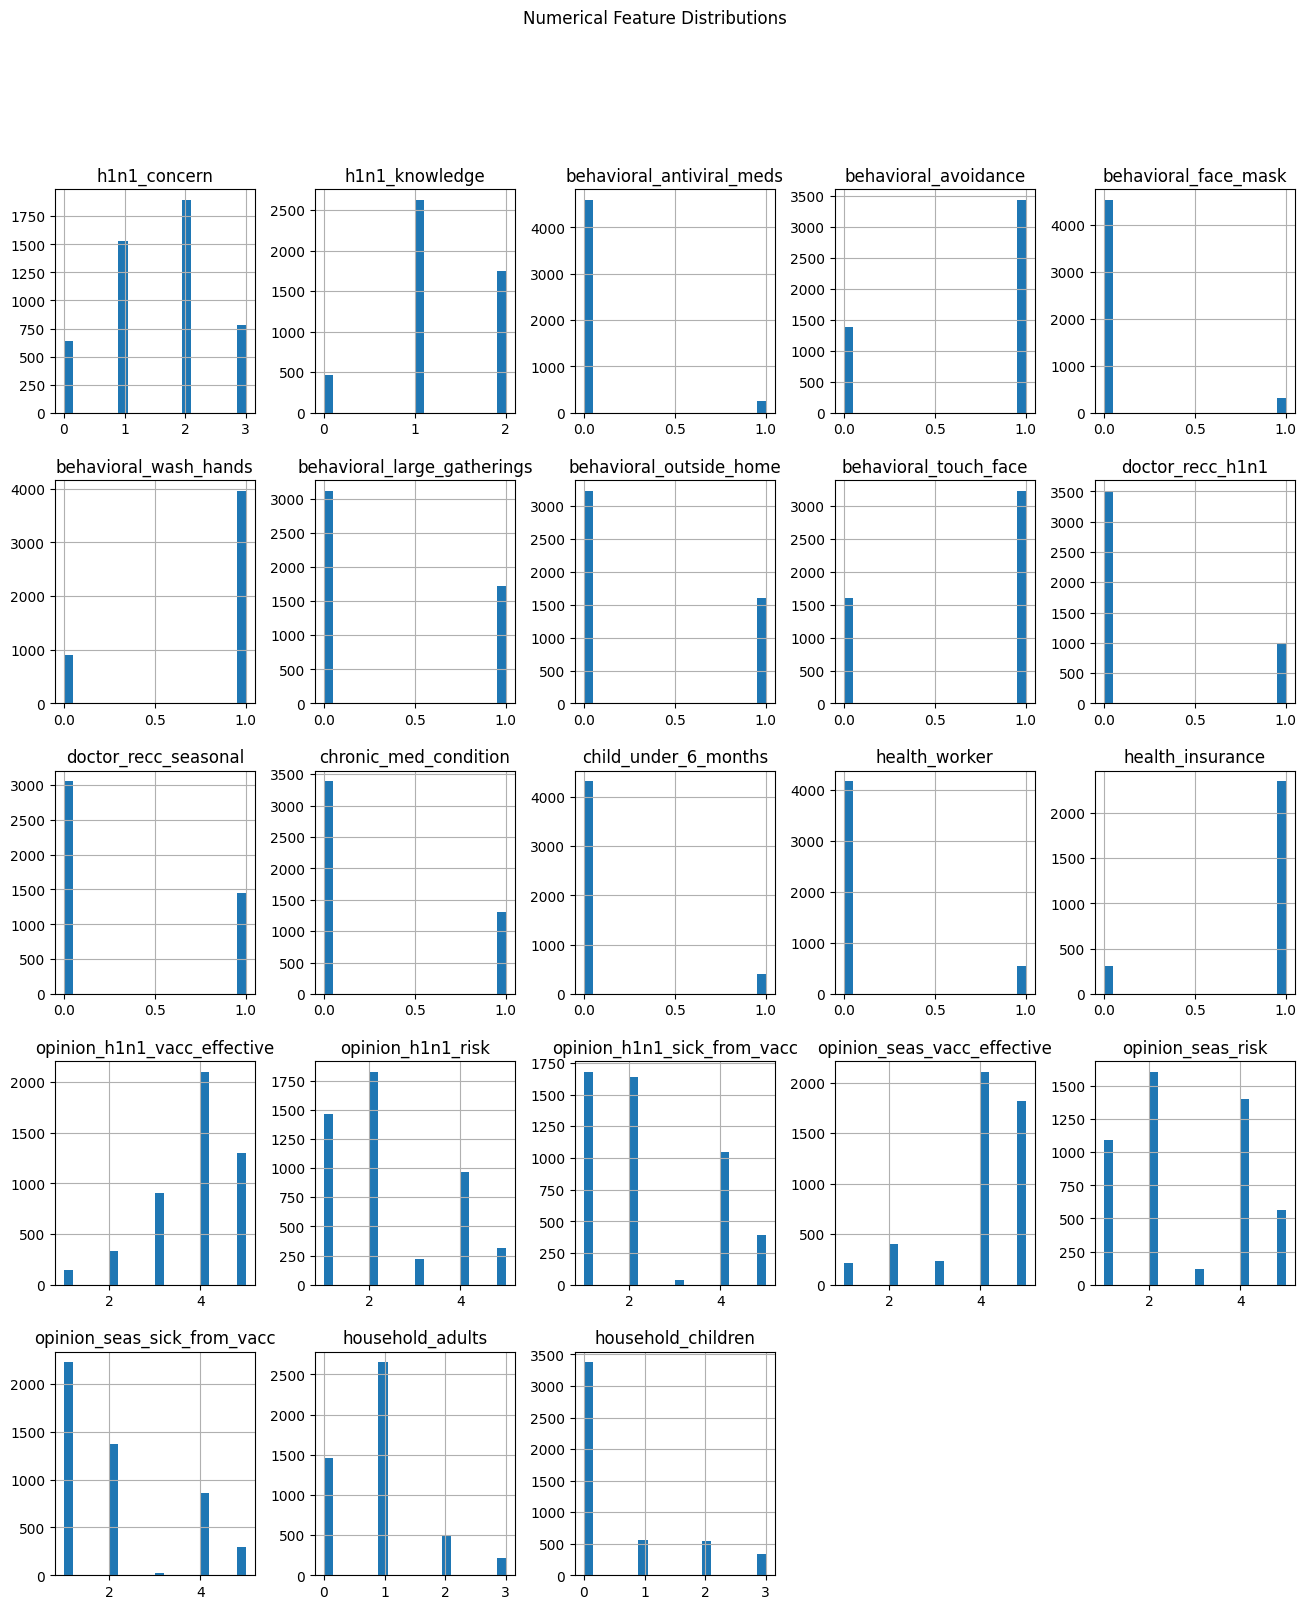

In [43]:
#NUMERICAL FEATURES
X_train[numerical_columns].hist(figsize=(16,18), bins=20)
plt.suptitle("Numerical Feature Distributions")
plt.show()

In [44]:
#CATEGORICAL FEATURES
for col in categorical_columns:
    print(f"\n{col}")
    print(X_train[col].value_counts(normalize=True).head())


age_group
age_group
65+ Years        0.254829
18 - 34 Years    0.205508
45 - 54 Years    0.202836
55 - 64 Years    0.196260
35 - 44 Years    0.140567
Name: proportion, dtype: float64

education
education
College Graduate    0.406209
Some College        0.276596
12 Years            0.227746
< 12 Years          0.089449
Name: proportion, dtype: float64

race
race
White                0.792026
Black                0.079737
Hispanic             0.067201
Other or Multiple    0.061036
Name: proportion, dtype: float64

sex
sex
Female    0.592067
Male      0.407933
Name: proportion, dtype: float64

income_poverty
income_poverty
<= $75,000, Above Poverty    0.573875
> $75,000                    0.301614
Below Poverty                0.124511
Name: proportion, dtype: float64

marital_status
marital_status
Married        0.529514
Not Married    0.470486
Name: proportion, dtype: float64

rent_or_own
rent_or_own
Own     0.759759
Rent    0.240241
Name: proportion, dtype: float64

employment_status
e

The univariate analysis shows that several numerical features are skewed, while categorical variables are often imbalanced with dominant categories. This highlights the need for proper preprocessing before modeling.

#### 2. BIVARIATE ANALYSIS- TARGET VS FEATURES
a) Numerical vs Target

In [45]:
for col in categorical_columns:
    cross_tab = pd.crosstab(X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.786000  0.214000
35 - 44 Years  0.782164  0.217836
45 - 54 Years  0.799392  0.200608
55 - 64 Years  0.761257  0.238743
65+ Years      0.775000  0.225000

education
h1n1_vaccine             0         1
education                           
12 Years          0.814109  0.185891
< 12 Years        0.803398  0.196602
College Graduate  0.748797  0.251203
Some College      0.786499  0.213501

race
h1n1_vaccine              0         1
race                                 
Black              0.822165  0.177835
Hispanic           0.788991  0.211009
Other or Multiple  0.787879  0.212121
White              0.775039  0.224961

sex
h1n1_vaccine         0         1
sex                             
Female        0.773690  0.226310
Male          0.790428  0.209572

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.791134  0.

b) Categorical vs Target

In [46]:
for col in categorical_columns:
    cross_tab = pd.crosstab(X_train[col], y_train['h1n1_vaccine'], normalize='index')
    print(f"\n{col}")
    print(cross_tab.head())


age_group
h1n1_vaccine          0         1
age_group                        
18 - 34 Years  0.786000  0.214000
35 - 44 Years  0.782164  0.217836
45 - 54 Years  0.799392  0.200608
55 - 64 Years  0.761257  0.238743
65+ Years      0.775000  0.225000

education
h1n1_vaccine             0         1
education                           
12 Years          0.814109  0.185891
< 12 Years        0.803398  0.196602
College Graduate  0.748797  0.251203
Some College      0.786499  0.213501

race
h1n1_vaccine              0         1
race                                 
Black              0.822165  0.177835
Hispanic           0.788991  0.211009
Other or Multiple  0.787879  0.212121
White              0.775039  0.224961

sex
h1n1_vaccine         0         1
sex                             
Female        0.773690  0.226310
Male          0.790428  0.209572

income_poverty
h1n1_vaccine                      0         1
income_poverty                               
<= $75,000, Above Poverty  0.791134  0.

The bivariate analysis indicates clear relationships between features and the target variables, suggesting that both demographic and behavioral factors influence vaccination outcomes and will be useful for prediction.

## PRE-PROCESSING

### ENCODING CATEGORICAL COLUMNS

In [47]:
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_ohe = pd.DataFrame(ohe.fit_transform(X_train_clean_cat), columns=ohe.get_feature_names_out(categorical_columns), index=X_train_clean.index)
X_test_ohe = pd.DataFrame(ohe.transform(X_test_clean_cat), columns=ohe.get_feature_names_out(categorical_columns), index=X_test_clean.index)


#### CONCATINATION

In [48]:
Final_X_train = pd.concat([X_train_clean_num, X_train_ohe], axis=1)
Final_X_test = pd.concat([X_test_clean_num, X_test_ohe], axis=1)

## MODELLING


Training **separate binary classifiers** for each target variable.

| Model | Purpose |
|---|---|
| Logistic Regression | Baseline — fast & interpretable |
| Decision Tree | Intermediate — non-linear, easy to explain |
| Random Forest (tuned) | Final model — strong performance |

**Primary metric:** ROC-AUC (ranges 0.5–1.0; higher is better)

### 1. Baseline — Logistic Regression

In [49]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(Final_X_train)
X_test_scaled = scaler.transform(Final_X_test)

lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))
lr.fit(X_train_scaled, y_train)
y_pred = lr.predict(X_test_scaled)

print("H1N1 Accuracy:", accuracy_score(y_test['h1n1_vaccine'], y_pred[:, 0]))
print("Seasonal Accuracy:", accuracy_score(y_test['seasonal_vaccine'], y_pred[:, 1]))

H1N1 Baseline Accuracy: 0.828266228430567
Seasonal Baseline Accuracy: 0.761709120788825


## Interpretation of my accuracy results
1.) H1N Accuracy - Out of all the thousands of patients in the test data, my Logistic Regression model looked at the urveys and correctly predicted whether they got the H1N1 vaccine or not 82.8% of the time.

2.) Seasonal Accuracy - Just like the H1N1 score, my your model looked at thousands of new test patients it had never seen before, checked out their survey answers, and successfully predicted their Seasonal vaccine status 76.17% of the time.

In [50]:
# Define the baseline model
base_lr = MultiOutputClassifier(LogisticRegression(max_iter=1000, random_state=42))

# Train it on the training data
base_lr.fit(X_train_scaled, y_train)
print("Base Logistic Regression model trained successfully!")


Base Logistic Regression model trained successfully!


In [51]:
logreg = MultiOutputClassifier(LogisticRegression(fit_intercept=False, solver='liblinear'))
model_log = logreg.fit(X_train_scaled, y_train)
model_log

MultiOutputClassifier(estimator=LogisticRegression(fit_intercept=False,
                                                   solver='liblinear'))

H1N1 Vaccine Split:
h1n1_vaccine
0    0.780358
1    0.219642
Name: proportion, dtype: float64

Seasonal Vaccine Split:
seasonal_vaccine
0    0.535443
1    0.464557
Name: proportion, dtype: float64
